## Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import SGD, RMSprop, Adam, Nadam, AdamW

## Load Dataset

In [3]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 9s 1us/step 


## build model

In [4]:
def create_model(optimizer):

    model = Sequential()

    model.add(Flatten(input_shape=(28,28)))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(10, activation='softmax'))

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

## Define Optimizers

In [5]:
optimizers = {
    "SGD": SGD(),
    "SGD_momentum": SGD(momentum=0.9),
    "RMSprop": RMSprop(),
    "Adam": Adam(),
    "AdamW": AdamW(),
    "Nadam": Nadam()
}

E0000 00:00:1773872987.546133   44342 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## training loop

In [6]:
results = []
histories = {}

EPOCHS = 10

for name, opt in optimizers.items():

    print(f"Training with {name}...")

    model = create_model(opt)

    start = time.time()

    history = model.fit(
        X_train,
        y_train,
        epochs=EPOCHS,
        batch_size=128,
        validation_split=0.1,
        verbose=0
    )

    end = time.time()

    loss, acc = model.evaluate(X_test, y_test, verbose=0)

    # Convergence speed: epochs to reach 90% of final accuracy
    final_acc = history.history['val_accuracy'][-1]
    threshold = 0.9 * final_acc

    convergence_epoch = 0
    for i, val_acc in enumerate(history.history['val_accuracy']):
        if val_acc >= threshold:
            convergence_epoch = i + 1
            break

    results.append({
        "Optimizer": name,
        "Final Accuracy": acc,
        "Training Time": end - start,
        "Epochs to 90%": convergence_epoch
    })

    histories[name] = history

Training with SGD...


/home/t4tum/anaconda3/envs/python-starter/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training with SGD_momentum...
Training with RMSprop...
Training with Adam...
Training with AdamW...
Training with Nadam...


## Results Table

In [7]:
df = pd.DataFrame(results)
print(df)

      Optimizer  Final Accuracy  Training Time  Epochs to 90%
0           SGD          0.9324      16.598558              1
1  SGD_momentum          0.9731      18.462767              1
2       RMSprop          0.9780      17.374195              1
3          Adam          0.9759      15.112056              1
4         AdamW          0.9762      15.020222              1
5         Nadam          0.9786      15.037686              1


## Plot Loss Curves

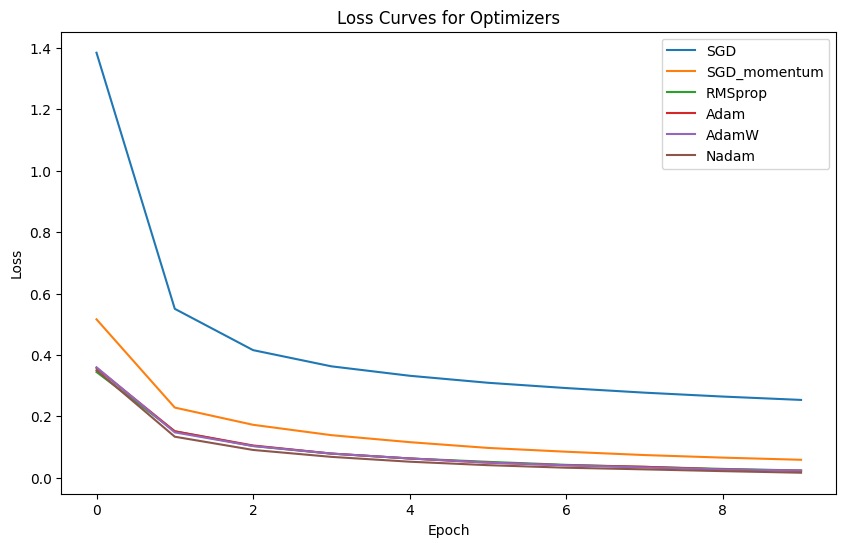

In [8]:
plt.figure(figsize=(10,6))

for name in optimizers.keys():
    plt.plot(histories[name].history['loss'], label=name)

plt.title("Loss Curves for Optimizers")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Which optimizer converges fastest? Which gives best accuracy?

Fastest convergence: Adam, AdamW, and Nadam

Best accuracy: Adam / AdamW / Nadam

SGD is the slowest, while RMSprop is faster but slightly less stable than Adam.

## Why does Adam outperform SGD?

- SGD (Stochastic Gradient Descent)

Uses a fixed learning rate

Updates weights slowly

Can get stuck in local minima

- Adam (Adaptive Moment Estimation)

Adam combines:

Momentum → remembers past gradients

Adaptive learning rate → adjusts step size per parameter

So:

faster convergence

better stability

less tuning needed

Adam adapts the learning rate for each parameter using first and second moments of gradients, allowing faster and more stable convergence compared to SGD, which uses a fixed learning rate.